# **Predictive Maintenance Analysis**
## **Objective**
The goal of this project is to analyze machine sensor data and understand the factors that lead to machine failure.
## **Importing Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **DataSheet**

In [2]:
data = pd.read_csv("C:/Users/Piyush Kumar/Desktop/lessgo/projects/predictive-maintenance-project/data/ai4i2020.csv")

data.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
data.shape

(10000, 14)

In [4]:
data.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

**As we can see this datasheet contains data of 10,000 observations of machine operating conditions such as temperature, torque, tool wear and rotational speed.**

## **Data Cleaning**

Some columns in the dataset act only as identifiers and do not provide useful information for predicting machine failures.

The columns **UDI** and **Product ID** uniquely identify each machine record, but they do not describe machine behavior or operating conditions.

So we will remove these columns from the dataset before performing further analysis.

In [6]:
data_clean = data.drop(["UDI", "Product ID"], axis=1)

## **Machine Failure**
The target variable is **Machine failure**, which indicates whether a machine is failing or not.

In [7]:
data_clean["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [8]:
data["Type"].unique()

array(['M', 'L', 'H'], dtype=object)

## **Encoding Categorical Variables**

The **Type** column represents different categories of machine products:

- **L** → Low quality / low cost machines  
- **M** → Medium quality machines  
- **H** → High quality machines  

These qualities of machine could also be the factor for machine failure. SO we will consider them too. Since machine learning algorithms require numerical inputs, categorical values cannot be used directly.

Therefore, we will convert the categories into numerical values:

- L → 0  
- M → 1  
- H → 2  

In [9]:
data_clean["Type"] = data_clean["Type"].map({"L":0, "M":1, "H":2})

## **Machine Failure Distribution**

We examine how many machines failed versus how many operated normally.

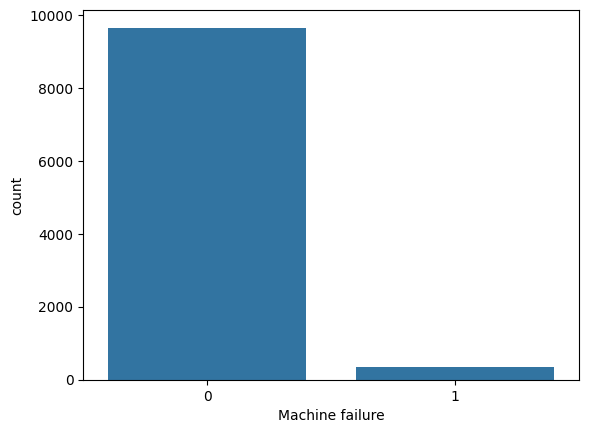

In [10]:
sns.countplot(x= "Machine failure", data = data_clean)
plt.show()

## **Basic Data Exploration**

We will now inspect the dataset to check the statistics of our machine operating conditions.

In [11]:
data_clean.describe()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,0.500300,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,0.671301,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,0.000000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,0.000000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,0.000000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,1.000000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,2.000000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


## **Distribution of Key Features**

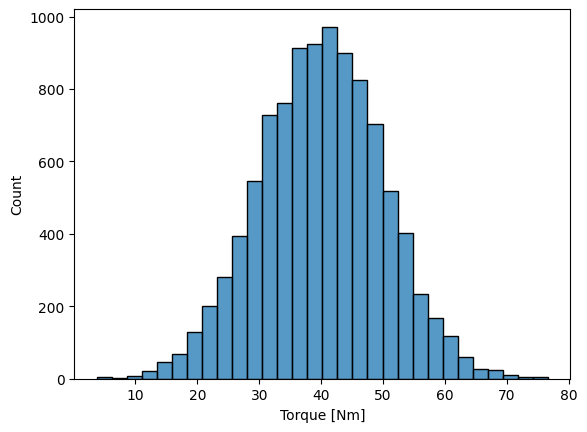

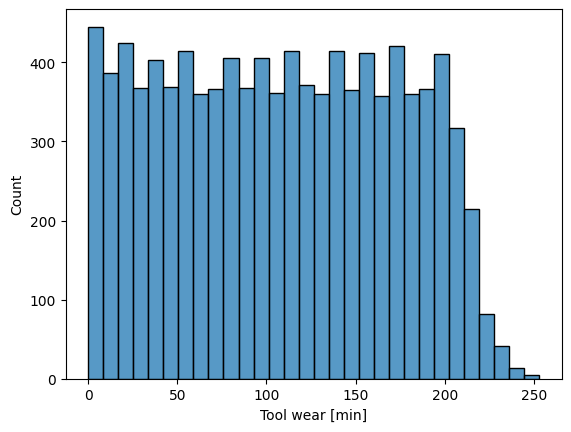

In [12]:
sns.histplot(data_clean["Torque [Nm]"], bins=30)
plt.show()

sns.histplot(data_clean["Tool wear [min]"], bins=30)
plt.show()

## **Correlation Between Variables**

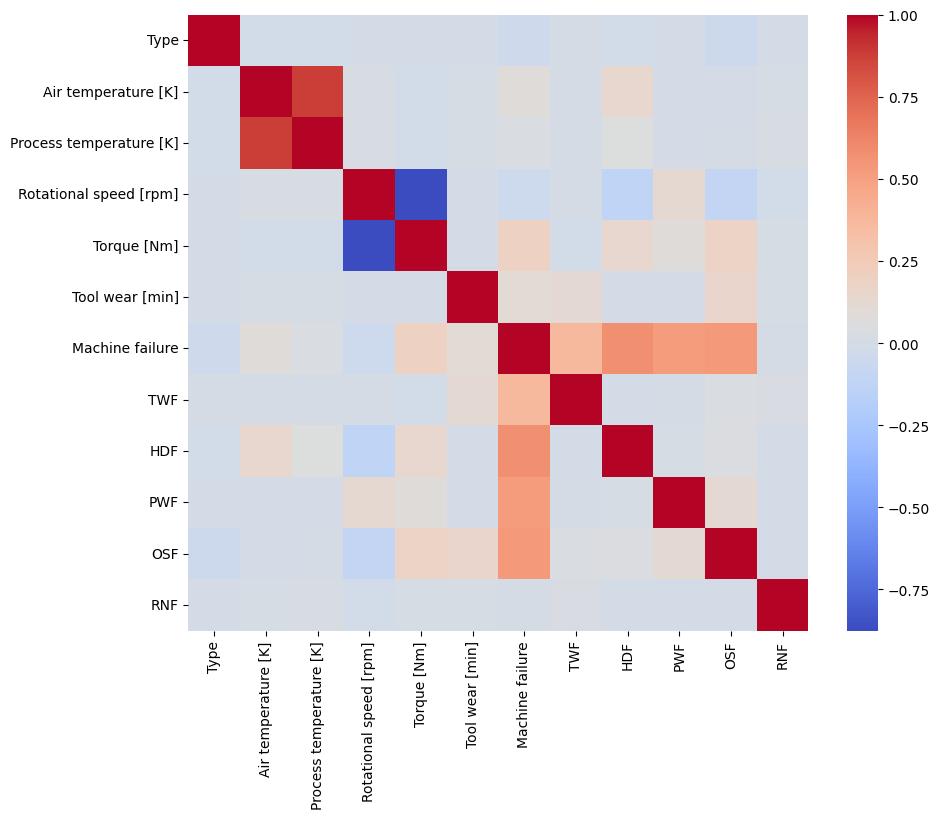

In [13]:
corr = data_clean.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm")
plt.show()

## **Feature And Target Separation**
For our machine learning model, we will divide our datasheet into Features(X) and Target variables(y).

X represents machine operating parameters such as temperature, rotational speed, torque, and tool wear.
y represents whether the machine failed (1) or operated normally (0).

In [14]:
X = data_clean.drop(["Machine failure", "TWF", "HDF", "PWF", "OSF", "RNF"], axis=1)
y = data_clean["Machine failure"]


### **Train–Test Split**

After separating the dataset, we will now split them into training and testing subsets.

* **X_train** contains the training features used to train the machine learning model.
* **X_test** contains the testing features used to evaluate the model’s performance on unseen data.
* **y_train** contains the target values used to train the machine learning model.
* **y_test** contains the target values used to evaluate the model’s performance on unseen data.

We will split the datasheet into 80-20 ratio so that enough data is provided for the model to learn effectively.


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 6)
(2000, 6)
(8000,)
(2000,)


### **Model Training and Prediction**

We will now train a Logistic Regression model using the training dataset to predict machine failures based on operational parameters such as temperature, torque, rotational speed, and tool wear.

We will fit the model using the training data (`X_train`, `y_train`) to learn relationships between machine conditions and failure outcomes. After training, wew will predict the testing dataset (`X_test`) and check the acccuracy.


In [16]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.974


### **Model Evaluation using Confusion Matrix**

To better understand the performance of the classification model, we will generate a confusion matrix.

The matrix provides four key values:

* **True Positives (TP):** Correctly predicted machine failures.
* **True Negatives (TN):** Correctly predicted normal machine operation.
* **False Positives (FP):** Predicted failure when the machine was actually functioning normally.
* **False Negatives (FN):** Failed to detect a machine failure.

This evaluation will give us a deeper insight into model performance beyond simple accuracy.


In [17]:
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print(f"\nOut of {cm[1].sum()} actual failures:")
print(f"Correctly detected: {cm[1][1]}")
print(f"Missed: {cm[1][0]}")
print(f"False alarms: {cm[0][1]}")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[1930    9]
 [  43   18]]

Out of 61 actual failures:
Correctly detected: 18
Missed: 43
False alarms: 9
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1939
           1       0.67      0.30      0.41        61

    accuracy                           0.97      2000
   macro avg       0.82      0.65      0.70      2000
weighted avg       0.97      0.97      0.97      2000



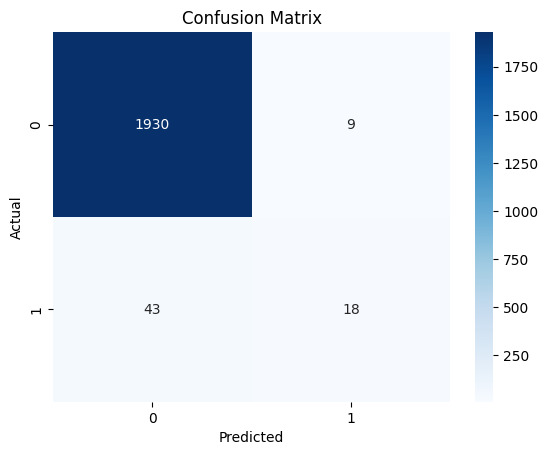

In [18]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

**Now our confusion matrix has correctly predicted 1930 machines as not failures but given us 9 false alarms that it is a failure. It has also correctly predicted 18 machines as failures but missed 43 failures. So our model is very good at predicting normal machines but not good at catching failures with an accuracy of 97.4%. It only catches 30% of failed machines.**

**Since a lot of failures were missed, we will now use a balanced version of the Logistic Regression model to detect more failures.**

In [19]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
X_bal = X
y_bal = y
X_bal_train, X_bal_test, y_bal_train, y_bal_test = train_test_split(X_bal, y_bal, test_size = 0.2, random_state=42)
model.fit(X_bal_train, y_bal_train)
y_bal_pred = model.predict(X_bal_test)
accuracy_bal = accuracy_score(y_bal_test, y_bal_pred)
print("Accuracy:", accuracy_bal)

from sklearn.metrics import confusion_matrix
cm_bal = confusion_matrix(y_bal_test, y_bal_pred)
print("Confusion Matrix:")
print(cm_bal)
print(f"\nOut of {cm_bal[1].sum()} actual failures:")
print(f"Correctly detected: {cm_bal[1][1]}")
print(f"Missed: {cm_bal[1][0]}")
print(f"False alarms: {cm_bal[0][1]}")
print(classification_report(y_bal_test, y_bal_pred))

Accuracy: 0.8175
Confusion Matrix:
[[1583  356]
 [   9   52]]

Out of 61 actual failures:
Correctly detected: 52
Missed: 9
False alarms: 356
              precision    recall  f1-score   support

           0       0.99      0.82      0.90      1939
           1       0.13      0.85      0.22        61

    accuracy                           0.82      2000
   macro avg       0.56      0.83      0.56      2000
weighted avg       0.97      0.82      0.88      2000



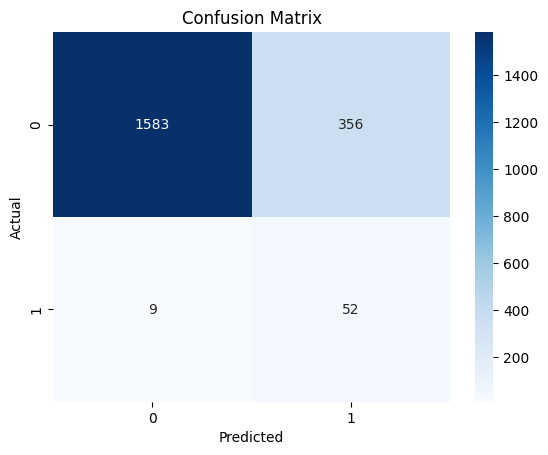

In [20]:
sns.heatmap(cm_bal, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

**Now our confusion matrix has correctly predicted 1583 machines as not failures but given us 356 false alarms that it is a failure. It has also correctly predicted 52 machines as failures but missed 9 failures. So our model is now very good at catching failures but gives a lot of false alarms. It has an accuracy of 81.75% and catches 85% of failed machines.**

**To further improve model performance, we will perform threshold tuning by adjusting the probability cutoff.**

In [21]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
X_bal_tun = X
y_bal_tun = y
X_bal_tun_train, X_bal_tun_test, y_bal_tun_train, y_bal_tun_test = train_test_split(X_bal_tun, y_bal_tun, test_size = 0.2, random_state=42)
model.fit(X_bal_tun_train, y_bal_tun_train)
y_bal_tun_pred = (model.predict_proba(X_bal_tun_test)[:, 1] > 0.7).astype(int)
accuracy_bal_tun = accuracy_score(y_bal_tun_test, y_bal_tun_pred)
print("Accuracy:", accuracy_bal_tun)

cm_bal_tun = confusion_matrix(y_bal_tun_test, y_bal_tun_pred)
print("Confusion Matrix:")
print(cm_bal_tun)
print(f"\nOut of {cm_bal_tun[1].sum()} actual failures:")
print(f"Correctly detected: {cm_bal_tun[1][1]}")
print(f"Missed: {cm_bal_tun[1][0]}")
print(f"False alarms: {cm_bal_tun[0][1]}")
print(classification_report(y_bal_tun_test, y_bal_tun_pred))

Accuracy: 0.9115
Confusion Matrix:
[[1778  161]
 [  16   45]]

Out of 61 actual failures:
Correctly detected: 45
Missed: 16
False alarms: 161
              precision    recall  f1-score   support

           0       0.99      0.92      0.95      1939
           1       0.22      0.74      0.34        61

    accuracy                           0.91      2000
   macro avg       0.60      0.83      0.64      2000
weighted avg       0.97      0.91      0.93      2000



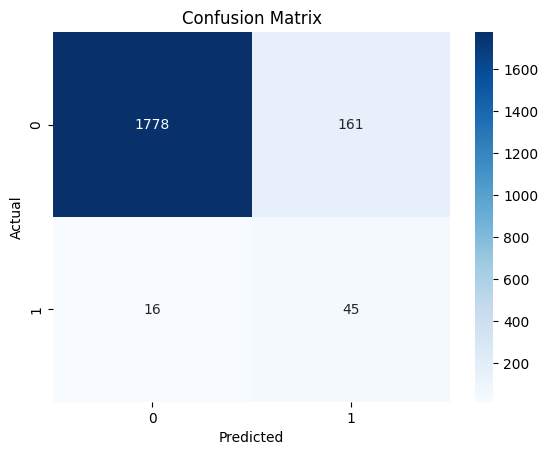

In [22]:
sns.heatmap(cm_bal_tun, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

**Now our confusion matrix has correctly predicted 1778 machines as not failures and given us 161 false alarms. It has correctly predicted 45 machines as failures and missed 16 failures. So our model is now good at catching failures and also doesn't give a lot of false alarms. It has an accuracy of 91.15% and catches 74% of failed machines.**

**Now, we will implement a Random Forest model to predict our failures as it is capable of capturing more complex relationships in the data compared to linear models.**

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
X_rf = X
y_rf = y
X_rf_train, X_rf_test, y_rf_train, y_rf_test = train_test_split(X_rf, y_rf, test_size = 0.2, random_state=42)
rf.fit(X_rf_train, y_rf_train)
y_rf_pred = rf.predict(X_rf_test)
accuracy_rf = accuracy_score(y_rf_test, y_rf_pred)
print("Accuracy:", accuracy_rf)
cm_rf = confusion_matrix(y_rf_test, y_rf_pred)
print("Confusion Matrix:")
print(cm_rf)
print(f"\nOut of {cm_rf[1].sum()} actual failures:")
print(f"Correctly detected: {cm_rf[1][1]}")
print(f"Missed: {cm_rf[1][0]}")
print(f"False alarms: {cm_rf[0][1]}")
print(classification_report(y_rf_test, y_rf_pred))

Accuracy: 0.9845
Confusion Matrix:
[[1933    6]
 [  25   36]]

Out of 61 actual failures:
Correctly detected: 36
Missed: 25
False alarms: 6
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1939
           1       0.86      0.59      0.70        61

    accuracy                           0.98      2000
   macro avg       0.92      0.79      0.85      2000
weighted avg       0.98      0.98      0.98      2000



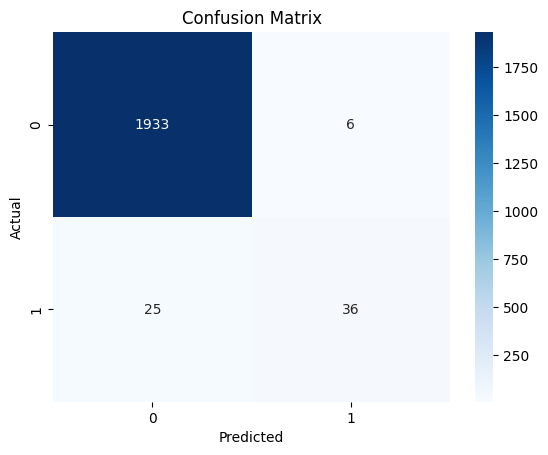

In [24]:
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

**Now our confusion matrix has correctly predicted 1933 machines as not failures and given us 6 false alarms. It has correctly predicted 36 machines as failures and missed 25 failures. So our model  is good at predicting non failure machines and also doesn't give a lot of false alarms. It has an accuracy of 98.45% and catches 59% of failed machines.**

In [25]:
rf_bal = RandomForestClassifier(random_state=42,  class_weight='balanced')
X_bal_rf = X
y_bal_rf = y
X_bal_rf_train, X_bal_rf_test, y_bal_rf_train, y_bal_rf_test = train_test_split(X_bal_rf, y_bal_rf, test_size = 0.2, random_state=42)
rf_bal.fit(X_bal_rf_train, y_bal_rf_train)
y_bal_rf_pred = rf_bal.predict(X_bal_rf_test)
accuracy_bal_rf = accuracy_score(y_bal_rf_test, y_bal_rf_pred)
print("Accuracy:", accuracy_bal_rf)
cm_bal_rf = confusion_matrix(y_bal_rf_test, y_bal_rf_pred)
print("Confusion Matrix:")
print(cm_bal_rf)
print(f"\nOut of {cm_bal_rf[1].sum()} actual failures:")
print(f"Correctly detected: {cm_bal_rf[1][1]}")
print(f"Missed: {cm_bal_rf[1][0]}")
print(f"False alarms: {cm_bal_rf[0][1]}")
print(classification_report(y_bal_rf_test, y_bal_rf_pred))

Accuracy: 0.982
Confusion Matrix:
[[1935    4]
 [  32   29]]

Out of 61 actual failures:
Correctly detected: 29
Missed: 32
False alarms: 4
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1939
           1       0.88      0.48      0.62        61

    accuracy                           0.98      2000
   macro avg       0.93      0.74      0.80      2000
weighted avg       0.98      0.98      0.98      2000



Text(0.5, 1.0, 'Confusion Matrix')

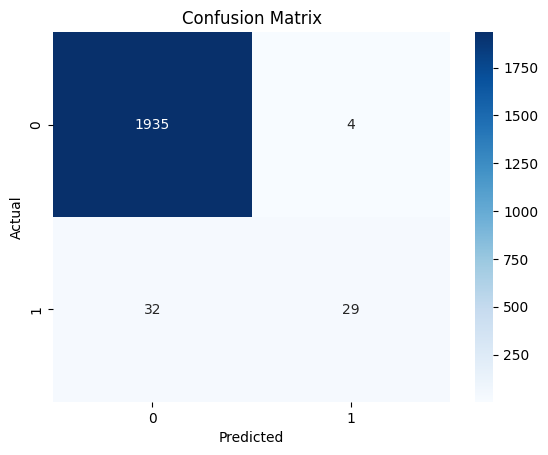

In [26]:
sns.heatmap(cm_bal_rf, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

**Now our confusion matrix has correctly predicted 1935 machines as not failures and given us 4 false alarms. It has correctly predicted 29 machines as failures and missed 32 failures. So our model is now worse than normal RainForest with an accuracy of 98.2 and catches 48% of failures.**

## **Using new Features**
Now we will add three new features using
Mechanical Engineering principles:

* **Power** = Torque × RPM × 2π/60 [Overpowered motors fail faster]
* **Temp_Difference** = Process Temp - Air Temp [Low difference = poor heat dissipation]
* **Wear_Strain** = Tool Wear × Torque [Combined effect of age and torque]

In [27]:
data_clean['Power [Watts]'] = data_clean['Torque [Nm]'] * data_clean['Rotational speed [rpm]'] * (2*np.pi / 60)
data_clean['Temp_Difference [K]'] = data_clean['Process temperature [K]'] - data_clean['Air temperature [K]']
data_clean['Wear_Progression'] = data_clean['Tool wear [min]'] * data_clean['Torque [Nm]']

print("New features")
print(data_clean[['Power [Watts]', 'Temp_Difference [K]', 'Wear_Progression']].head())

New features
   Power [Watts]  Temp_Difference [K]  Wear_Progression
0    6951.590560                 10.5               0.0
1    6826.722724                 10.5             138.9
2    7749.387543                 10.4             247.0
3    5927.504659                 10.4             276.5
4    5897.816608                 10.5             360.0


In [28]:
print("FAILED MACHINES vs HEALTHY MACHINES\n")

failed = data_clean[data_clean['Machine failure'] == 1]
healthy = data_clean[data_clean['Machine failure'] == 0]

print(f"Average Power - Failed: {failed['Power [Watts]'].mean():.2f}W | Healthy: {healthy['Power [Watts]'].mean():.2f}W")
print(f"Average Temp Diff - Failed: {failed['Temp_Difference [K]'].mean():.2f}K | Healthy: {healthy['Temp_Difference [K]'].mean():.2f}K")
print(f"Average Wear Strain - Failed: {failed['Wear_Progression'].mean():.2f} | Healthy: {healthy['Wear_Progression'].mean():.2f}")

FAILED MACHINES vs HEALTHY MACHINES

Average Power - Failed: 7282.82W | Healthy: 6244.55W
Average Temp Diff - Failed: 9.40K | Healthy: 10.02K
Average Wear Strain - Failed: 7187.94 | Healthy: 4213.84


### **Key Finding**
Failed machines showed:
- 17% higher average power output
- 70% higher wear strain
- Lower temperature difference indicating poor cooling

In [29]:
X_new = data_clean.drop(["Machine failure", "TWF", "HDF", "PWF", "OSF", "RNF"], axis=1)
y_new = data_clean["Machine failure"]
X_new_train, X_new_test, y_new_train, y_new_test = train_test_split(X_new, y_new, test_size = 0.2, random_state=42)
model = LogisticRegression(max_iter=1000)
model.fit(X_new_train, y_new_train)
y_new_pred = model.predict(X_new_test)
from sklearn.metrics import accuracy_score

accuracy_new = accuracy_score(y_new_test, y_new_pred)
print("Accuracy:", accuracy_new)
cm_new = confusion_matrix(y_new_test, y_new_pred)
print("Confusion Matrix:")
print(cm_new)
print(f"\nOut of {cm_new[1].sum()} actual failures:")
print(f"Correctly detected: {cm_new[1][1]}")
print(f"Missed: {cm_new[1][0]}")
print(f"False alarms: {cm_new[0][1]}")
print(classification_report(y_new_test, y_new_pred))

Accuracy: 0.972
Confusion Matrix:
[[1926   13]
 [  43   18]]

Out of 61 actual failures:
Correctly detected: 18
Missed: 43
False alarms: 13
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1939
           1       0.58      0.30      0.39        61

    accuracy                           0.97      2000
   macro avg       0.78      0.64      0.69      2000
weighted avg       0.97      0.97      0.97      2000



Text(0.5, 1.0, 'Confusion Matrix')

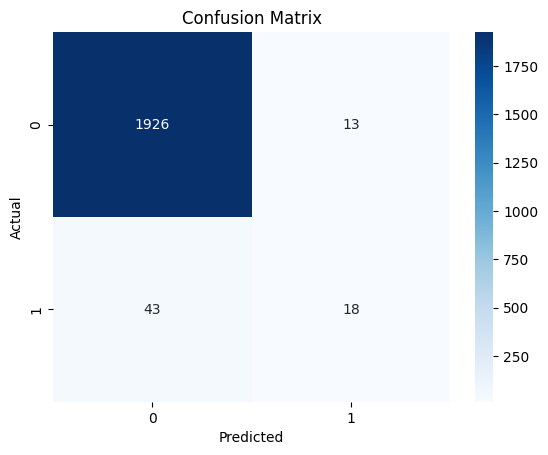

In [30]:
sns.heatmap(cm_new, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

**Now our confusion matrix has correctly predicted 1926 machines as not failures and given us 13 false alarms. It has correctly predicted 18 machines as failures and missed 43 failures. So our model is good at catching non failures and fails to catch a lot of failures. It has an accuracy of 97.2% and catches 30% of failed machines.**

In [31]:
model = LogisticRegression(max_iter=2000, class_weight='balanced')
X_new_bal = X_new
y_new_bal = y_new
X_new_bal_train, X_new_bal_test, y_new_bal_train, y_new_bal_test = train_test_split(X_new_bal, y_new_bal, test_size = 0.2, random_state=42)
model.fit(X_new_bal_train, y_new_bal_train)
y_new_bal_pred = model.predict(X_new_bal_test)
accuracy_new_bal = accuracy_score(y_new_bal_test, y_new_bal_pred)
print("Accuracy:", accuracy_new_bal)


cm_new_bal = confusion_matrix(y_new_bal_test, y_new_bal_pred)
print("Confusion Matrix:")
print(cm_new_bal)
print(f"\nOut of {cm_new_bal[1].sum()} actual failures:")
print(f"Correctly detected: {cm_new_bal[1][1]}")
print(f"Missed: {cm_new_bal[1][0]}")
print(f"False alarms: {cm_new_bal[0][1]}")
print(classification_report(y_new_bal_test, y_new_bal_pred))

Accuracy: 0.8525
Confusion Matrix:
[[1655  284]
 [  11   50]]

Out of 61 actual failures:
Correctly detected: 50
Missed: 11
False alarms: 284
              precision    recall  f1-score   support

           0       0.99      0.85      0.92      1939
           1       0.15      0.82      0.25        61

    accuracy                           0.85      2000
   macro avg       0.57      0.84      0.59      2000
weighted avg       0.97      0.85      0.90      2000



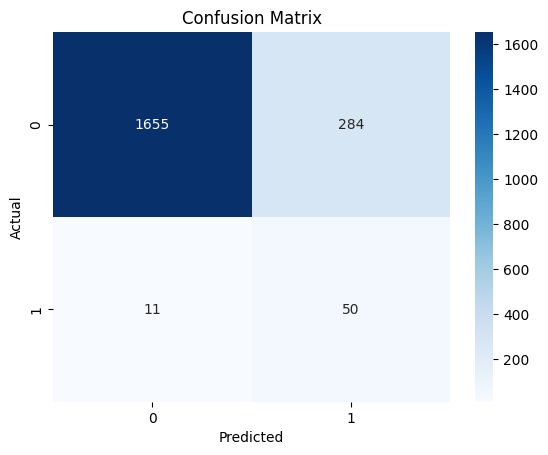

In [32]:
sns.heatmap(cm_new_bal, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

**Now our confusion matrix has correctly predicted 1655 machines as not failures and given us 284 false alarms. It has correctly predicted 50 machines as failures and missed 11 failures. So our model  is good at predicting failure machines and but gives a lot of false alarms. It has an accuracy of 85.25% and catches 81% of failed machines.**

In [33]:
model = LogisticRegression(max_iter=2000, class_weight='balanced')
X_new_bal_tun = X_new
y_new_bal_tun = y_new
X_new_bal_tun_train, X_new_bal_tun_test, y_new_bal_tun_train, y_new_bal_tun_test = train_test_split(X_new_bal_tun, y_new_bal_tun, test_size = 0.2, random_state=42)
model.fit(X_new_bal_tun_train, y_new_bal_tun_train)
y_new_bal_tun_pred = (model.predict_proba(X_new_bal_tun_test)[:, 1] > 0.7).astype(int)
accuracy_new_bal_tun = accuracy_score(y_new_bal_tun_test, y_new_bal_tun_pred)
print("Accuracy:", accuracy_new_bal_tun)

cm_new_bal_tun = confusion_matrix(y_new_bal_tun_test, y_new_bal_tun_pred)
print("Confusion Matrix:")
print(cm_new_bal_tun)
print(f"\nOut of {cm_new_bal_tun[1].sum()} actual failures:")
print(f"Correctly detected: {cm_new_bal_tun[1][1]}")
print(f"Missed: {cm_new_bal_tun[1][0]}")
print(f"False alarms: {cm_new_bal_tun[0][1]}")
print(classification_report(y_new_bal_tun_test, y_new_bal_tun_pred))

Accuracy: 0.9175
Confusion Matrix:
[[1792  147]
 [  18   43]]

Out of 61 actual failures:
Correctly detected: 43
Missed: 18
False alarms: 147
              precision    recall  f1-score   support

           0       0.99      0.92      0.96      1939
           1       0.23      0.70      0.34        61

    accuracy                           0.92      2000
   macro avg       0.61      0.81      0.65      2000
weighted avg       0.97      0.92      0.94      2000



Text(0.5, 1.0, 'Confusion Matrix')

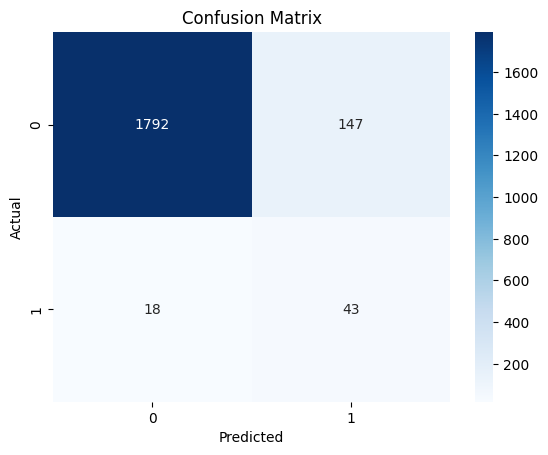

In [34]:
sns.heatmap(cm_new_bal_tun, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

**Now our confusion matrix has correctly predicted 1792 machines as not failures and given us 147 false alarms. It has correctly predicted 43 machines as failures and missed 18 failures. So our model  is good at predicting failure machines and gives less false alarms. It has an accuracy of 91.75% and catches 70% of failed machines.**

In [35]:
rf_new = RandomForestClassifier(random_state=42)
X_rf_new = X_new
y_rf_new = y_new
X_rf_new_train, X_rf_new_test, y_rf_new_train, y_rf_new_test = train_test_split(X_rf_new, y_rf_new, test_size = 0.2, random_state=42)
rf_new.fit(X_new_train, y_new_train)
y_rf_new_pred = rf_new.predict(X_rf_new_test)
cm_rf_new = confusion_matrix(y_rf_new_test, y_rf_new_pred)
accuracy_rf_new = accuracy_score(y_rf_new_test, y_rf_new_pred)
print("Accuracy:", accuracy_rf_new)

print("Confusion Matrix:")
print(cm_rf_new)
print(f"\nOut of {cm_rf_new[1].sum()} actual failures:")
print(f"Correctly detected: {cm_rf_new[1][1]}")
print(f"Missed: {cm_rf_new[1][0]}")
print(f"False alarms: {cm_rf_new[0][1]}")
print(classification_report(y_new_test, y_new_pred))

Accuracy: 0.9935
Confusion Matrix:
[[1938    1]
 [  12   49]]

Out of 61 actual failures:
Correctly detected: 49
Missed: 12
False alarms: 1
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1939
           1       0.58      0.30      0.39        61

    accuracy                           0.97      2000
   macro avg       0.78      0.64      0.69      2000
weighted avg       0.97      0.97      0.97      2000



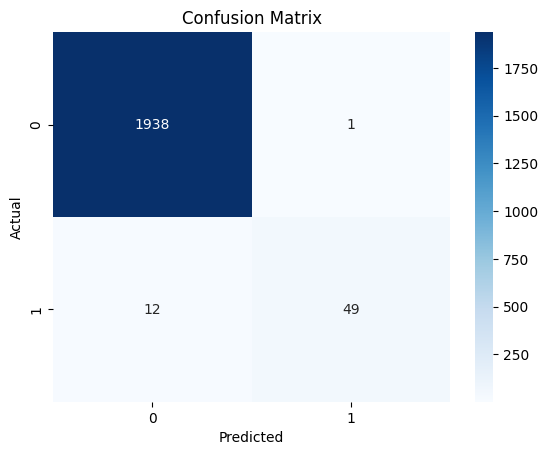

In [36]:
sns.heatmap(cm_rf_new, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

**Now our confusion matrix has correctly predicted 1938 machines as not failures and given us 1 false alarms. It has correctly predicted 49 machines as failures and missed 12 failures. So our model is now good at catching failures and has greatly dropped giving false alarms. It has an accuracy of 99.35% and catches 80% of failed machines.**

In [37]:
rf_new_bal = RandomForestClassifier(random_state=42,  class_weight='balanced')
X_rf_new_bal = X_new
y_rf_new_bal = y_new
X_rf_new_bal_train, X_rf_new_bal_test, y_rf_new_bal_train, y_rf_new_bal_test = train_test_split(X_rf_new_bal, y_rf_new_bal, test_size = 0.2, random_state=42)
rf_new_bal.fit(X_rf_new_bal_train, y_rf_new_bal_train)
y_rf_new_bal_pred = rf_new_bal.predict(X_rf_new_bal_test)
cm_rf_new_bal = confusion_matrix(y_rf_new_bal_test, y_rf_new_bal_pred)
accuracy_rf_new_bal = accuracy_score(y_rf_new_bal_test, y_rf_new_bal_pred)
print("Accuracy:", accuracy_rf_new_bal)

print("Confusion Matrix:")
print(cm_rf_new_bal)
print(f"\nOut of {cm_rf_new_bal[1].sum()} actual failures:")
print(f"Correctly detected: {cm_rf_new_bal[1][1]}")
print(f"Missed: {cm_rf_new_bal[1][0]}")
print(f"False alarms: {cm_rf_new_bal[0][1]}")
print(classification_report(y_rf_new_bal_test, y_rf_new_bal_pred))

Accuracy: 0.992
Confusion Matrix:
[[1938    1]
 [  15   46]]

Out of 61 actual failures:
Correctly detected: 46
Missed: 15
False alarms: 1
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1939
           1       0.98      0.75      0.85        61

    accuracy                           0.99      2000
   macro avg       0.99      0.88      0.92      2000
weighted avg       0.99      0.99      0.99      2000



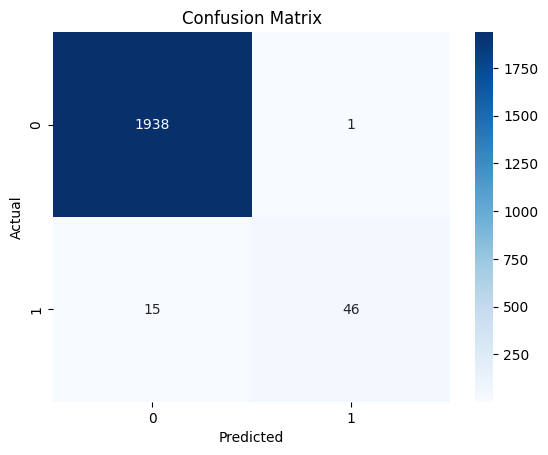

In [38]:
sns.heatmap(cm_rf_new_bal, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

**Now our confusion matrix has correctly predicted 1938 machines as not failures and given us 1 false alarms. It has correctly predicted 46 machines as failures and missed 15 failures. Now it is same as normal Random Forest at predicting machines and worse than it at catching failures.**

## **Feature Importance Analysis**

We will now analyze which machine parameters contribute most to machine failure. Each importance score represents the strength of the relationship between a feature and the probability of machine failure.

By examining these scores, it is possible to identify which operational parameters have the greatest influence on machine reliability.


                   Feature  Importance
8         Wear_Progression    0.208539
6            Power [Watts]    0.192570
3   Rotational speed [rpm]    0.180757
7      Temp_Difference [K]    0.131352
4              Torque [Nm]    0.120951
5          Tool wear [min]    0.051844
1      Air temperature [K]    0.044967
2  Process temperature [K]    0.037031
0                     Type    0.031990


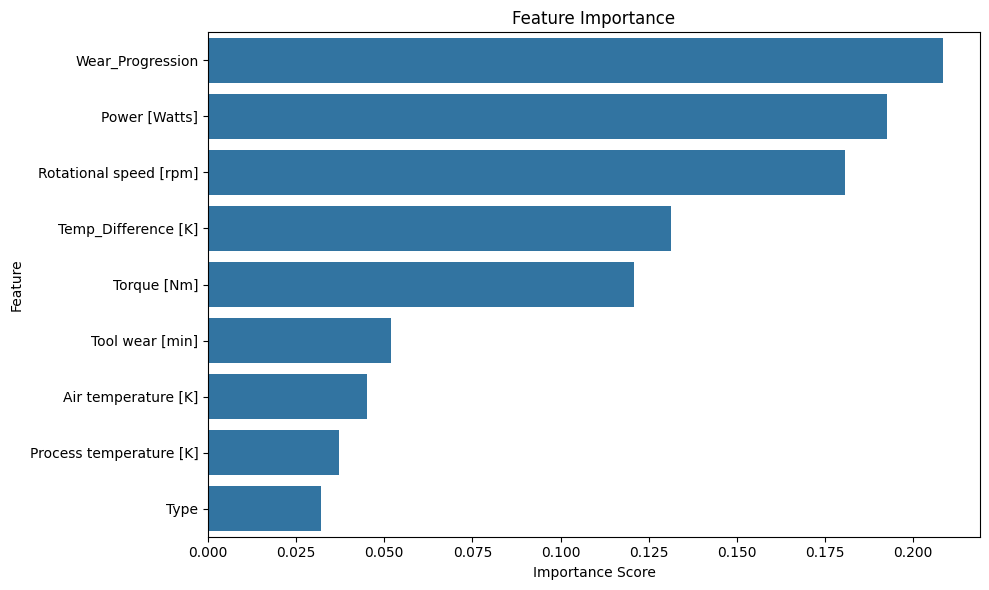

In [39]:
feature_importance_new = pd.DataFrame({
    'Feature': X_new.columns,
    'Importance': rf_new.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance_new)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_new
)
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Model Comparison and Final Selection

Two models were evaluated: Logistic Regression and Random Forest, tested both
with and without physics-based features.

### Without new Features
| Model | Failures Detected | False Alarms |
|-------|------------------|--------------|
| Logistic Regression (balanced) | 52/61 | 356 |
| Logistic Regression (tuned) | 45/61 | 161 |
| Random Forest | 36/61 | 6 |

Without new features, Logistic Regression (tuned) is the best model.

### With new Features
| Model | Failures Detected | False Alarms |
|-------|------------------|--------------|
| Logistic Regression (balanced) | 50/61 | 284 |
| Logistic Regression (tuned) | 43/61 | 147 |
| **Random Forest (Final Model)** | **49/61** | **1** |

### Key Finding
Adding new features completely changed the model selection decision.
Without new features, Logistic Regression was the best choice. After adding
Power, Wear_Strain and Temp_Difference features, Random Forest achieved near
identical failure detection (49 vs 50) but reduced false alarms from 284 to just 1.

### Final Model Selection
Random Forest with physics features was selected as the final model because:
- Detects 49 out of 61 failures (80%)
- Only 1 false alarm per 2000 observations
- 98% precision meaning alerts are almost always correct
- Physics features contributed 39% of predictive power

In a real factory environment, 284 false alarms would cause maintenance teams
to start ignoring alerts. With only 1 false alarm, every alert is taken seriously.

## **Conclusion**

In this project, I developed a system to predict when industrial machinery is likely to fail before a breakdown actually occurs. Using raw sensor data, my goal was to move beyond reactive repairs and toward a smarter, data-driven maintenance strategy.

### **The Approach**
I started by analyzing and cleaning the data. I then implemented two different approaches: a **Logistic Regression** model as a baseline and a **Random Forest** for more complex pattern recognition. 
In Logistic Regression, I followed a three-step optimization process:

* Baseline (Normal) Model: Used default parameters to understand the raw predictive power of the features.
* Balanced Model: Applied balanced weight class for catching more failures.
* Tuned Model: Applied >70% Probability Threshold for the best optimization.

After this I added new features — **Power consumption**, **Temperature Difference** and **Wear Progression** for better realisation of combined effects of features on machines. Doing this allowed me to capture more failed machines. I applied the same approach of implementing **Logistic Regression** and **Random Forest**.

**I learned that adding new features(like calculating Power from Torque and RPM) often provides more value than simply tuning model hyperparameters.**

### **The "Accuracy" Trap**
A key takeaway from this project was that **high accuracy can be misleading.** While the Random Forest model looked better on paper with a higher overall accuracy score, it was too "cautious" as it missed a significant number of actual failures. In a factory setting, a missed failure means expensive downtime and potential hardware damage.

### **Final Selection & Impact**
I ultimately chose the **Random Forest** model as it predicted near identical failurers and only gave us 1 false alarm.

This project highlights that data science isn't just about chasing the highest score; it’s about choosing the right tool for the specific risks of the job.

In [40]:
import joblib

joblib.dump(rf_new, r'C:\Users\Piyush Kumar\Desktop\lessgo\projects\predictive-maintenance-project\model.pkl')

print("Model saved successfully!")

Model saved successfully!


In [41]:
data_clean.columns


Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Power [Watts]',
       'Temp_Difference [K]', 'Wear_Progression'],
      dtype='object')